In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install datasets==2.20.0
!pip install octis==1.14.0 --no-deps
!pip install scikit-learn pandas scipy gensim nltk spacy
!pip install gensim==4.3.3
!pip install autoray==0.6.11
!pip uninstall -y jax jaxlib
!pip install jax==0.4.10 jaxlib==0.4.10 --find-links https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install pennylane==0.37.0
!pip install -U kaleido==0.2.1

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Ignored the following yanked versions: 0.4.32
ERROR: Could not find a version that satisfies the requirement jaxlib==0.4.10 (from versions: 0.4.17+cuda11.cudnn86, 0.4.17+cuda12.cudnn89, 0.4.18, 0.4.18+cuda11.cudnn86, 0.4.18+cuda12.cudnn89, 0.4.19, 0.4.19+cuda11.cudnn86, 0.4.19+cuda12.cudnn89, 0.4.20, 0.4.20+cuda11.cudnn86, 0.4.20+cuda12.cudnn89, 0.4.21, 0.4.21+cuda11.cudnn86, 0.4.21+cuda12.cudnn89, 0.4.22, 0.4.22+cuda11.cudnn86, 0.4.22+cuda12.cudnn89, 0.4.23, 0.4.23+cuda11.cudnn86,

In [2]:
import os
import re
import ast
import glob
import json
import math
import numpy as np
import pandas as pd
import plotly.express as px
from functools import reduce
from datetime import datetime

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
m_n = lambda x: x.replace("hybrid","Hybrid").replace("classical","Classical").replace("vae","VAE")

In [5]:
"""
* ==============================================
* All credit to https://github.com/xuweijieshuai/Neural-Topic-Modeling-vmf/blob/main/src/topicmodeling/preprocess.py
* ==============================================
"""
from collections import defaultdict
import multiprocessing
from multiprocessing import Pool
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
import numpy as np
import pandas as pd
import string

class TextProcessor:

    def __init__(self, data,all):
        self.all = all
        self.data = data
        self.bow = None
        self.word_to_index = None
        self.index_to_word = None
        self.lemmatized_sentences = None
        nltk.download('punkt')
        nltk.download('wordnet')
        nltk.download('averaged_perceptron_tagger')
        nltk.download('stopwords')

    def __str__(self):
        """String representation of TextProcessor"""
        return f'TextProcessor(len(data)={len(self.data)})'


    def get_wordnet_pos(self, word):
        tag = pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}

        return tag_dict.get(tag, wordnet.NOUN)

    def convert_to_bag_of_words(self, list_of_lists, min_freq=10, max_freq_ratio=0.05):
        if self.all:
          min_freq = 0
          max_freq_ratio=1
        # Your existing implementation here
        word_freq = defaultdict(int)
        for lst in list_of_lists:
            for word in lst:
                word_freq[word] += 1
        max_freq = len(list_of_lists) * max_freq_ratio
        vocabulary = {word for word, count in word_freq.items() if min_freq <= count < max_freq}
        word_to_index = {word: i for i, word in enumerate(vocabulary)}
        index_to_word = {i: word for word, i in word_to_index.items()}
        num_lists = len(list_of_lists)
        vocab_size = len(vocabulary)
        bag_of_words = [[0] * vocab_size for _ in range(num_lists)]
        self.lemmas = []
        for i, lst in enumerate(list_of_lists):
            lemma = []
            for word in lst:
                lemma = [word for word in lst if word in word_to_index]
                if word in word_to_index:
                    index = word_to_index[word]
                    bag_of_words[i][index] += 1

            self.lemmas.append(lemma)

        self.bow, self.word_to_index, self.index_to_word = bag_of_words, word_to_index, index_to_word

    def worker(self, data_chunk):
        lemmatizer = WordNetLemmatizer()
        stop_words = set(stopwords.words('english'))
        table = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
        lemmatized_chunk = []

        for sentence in data_chunk:
            sentence = sentence.translate(table).lower().replace("  ", " ")
            words = word_tokenize(sentence)
            lemmatized_words = [lemmatizer.lemmatize(word, self.get_wordnet_pos(word)) for word in words if word not in stop_words and lemmatizer.lemmatize(word, self.get_wordnet_pos(word)) != '' ]
            lemmatized_words = [i for i in lemmatized_words if len(i) >= 3 and (not i.isdigit()) and ' ' not in i]
            lemmatized_chunk.append(lemmatized_words)

        return lemmatized_chunk

    def lemmatize_sentences(self):
        num_processes = multiprocessing.cpu_count()
        pool = Pool(num_processes)
        data_chunks = np.array_split(self.data, num_processes)
        results = pool.map(self.worker, data_chunks)
        pool.close()
        pool.join()
        self.lemmatized_sentences = [j for i in results for j in i]

    def process(self):
        self.lemmatize_sentences()
        self.convert_to_bag_of_words(self.lemmatized_sentences)


In [14]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

from octis.dataset.dataset import Dataset
from random import randint

dataset = Dataset()
dataset.fetch_dataset("20NewsGroup")

corpus = dataset.get_corpus()
labels = dataset.get_labels()

twenty_news = {}

CLASSES = list(set(labels))

label_counts = {label: labels.count(label) for label in CLASSES}

samples = dict((c, [randint(1, label_counts[c]) for _ in range(10)]) for c in CLASSES)

counters = {c: 0 for c in CLASSES}

for words, label in zip(corpus, labels):
  counters[label] += 1
  if label in samples and counters[label] in samples[label]:
    if label not in twenty_news:
      twenty_news[label] = []
    twenty_news[label].append(' '.join(words))

for key in twenty_news.keys():
  twenty_news[key] = TextProcessor(twenty_news[key], True)
  twenty_news[key].process()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet t

In [13]:
MODELS = {
    "classical vae":"classical-vae-3-0.628606#18",
    "classical vae prob":"classical-vae-(prob)-4-0.624665#16",
    "hybrid vae":"hybrid-vae-3-0.619731#17",
    "hybrid vae prob":"hybrid-vae-(prob)-1-0.625396#10"
    }
def load_model(model_class,model_name):
  model_path = f"/content/drive/MyDrive/master/ntm/twenty_news models/{model_name}.pth"
  checkpoint = torch.load(model_path,map_location=torch.device('cpu'),weights_only=False)
  vocab = checkpoint["vocab"]
  model = model_class(vocab)
  model.load_state_dict(checkpoint['model_state_dict'])
  return model,vocab

TOPIC_COUNT = 20

In [12]:
from torch.nn import functional as F
from torch import nn
import numpy as np
import gensim
import torch


class ClassicalVAESLS(nn.Module):
    def __init__(self,vocab):
        super(ClassicalVAESLS, self).__init__()

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = nn.Linear(1024, 10)
        self.encoder_fc10_logvar = nn.Linear(1024, 10)
        self.gsm_fc = nn.Linear(10, TOPIC_COUNT)

        self.bn_mu =  nn.BatchNorm1d(
            10, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            10, affine=False
        )

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))
        return self.bn_mu(F.tanh(self.encoder_fc10_mu(batch))),self.bn_log_var(F.tanh(self.encoder_fc10_logvar(batch)))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: classical vae, Pretrained Model: glove-wiki-gigaword-300"


In [11]:
from torch.nn import functional as F
from torch import nn
import numpy as np
import gensim
import torch

class ClassicalVAELLS(nn.Module):
    def __init__(self,vocab):
        super(ClassicalVAELLS, self).__init__()

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = nn.Linear(1024, 32)
        self.encoder_fc10_logvar = nn.Linear(1024, 32)
        self.gsm_fc = nn.Linear(32, TOPIC_COUNT)

        self.bn_mu =  nn.BatchNorm1d(
            32, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            32, affine=False
        )

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))
        return self.bn_mu(F.tanh(self.encoder_fc10_mu(batch))),self.bn_log_var(F.tanh(self.encoder_fc10_logvar(batch)))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: classical vae (prob), Pretrained Model: glove-wiki-gigaword-300"

In [10]:
from torch.nn import functional as F
import pennylane as qml
from torch import nn
import numpy as np
import gensim
import torch


class HybridVAESLS(nn.Module):
    def __init__(self,vocab):
        super(HybridVAESLS, self).__init__()

        WIRES = 10
        dev = qml.device('default.qubit', wires=WIRES)
        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            qml.templates.AmplitudeEmbedding(features=inputs, wires=range(WIRES), normalize=True)
            qml.templates.StronglyEntanglingLayers(weights, wires=range(WIRES))
            return [qml.expval(op=qml.PauliZ(j)) for j in range(WIRES)]

        circuit_weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=WIRES)}

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.encoder_fc10_logvar = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.gsm_fc = nn.Linear(10, TOPIC_COUNT)

        self.mu_alpha = nn.Parameter(torch.randn(10))
        self.log_var_alpha = nn.Parameter(torch.randn(10))

        self.bn_mu =  nn.BatchNorm1d(
            10, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            10, affine=False
        )

        self.temperature = nn.Parameter(torch.randn(1).squeeze())

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))

        return self.bn_mu(self.mu_alpha*self.encoder_fc10_mu(batch)),self.bn_log_var(self.log_var_alpha*self.encoder_fc10_logvar(batch))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.temperature*self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: hybrid vae, Pretrained Model: glove-wiki-gigaword-300, Quantum Circuit: AE->SEL->SEL->SEL-><Z>"

In [9]:
from torch.nn import functional as F
import pennylane as qml
from torch import nn
import numpy as np
import gensim
import torch


class HybridVAELLS(nn.Module):
    def __init__(self,vocab):
        super(HybridVAELLS, self).__init__()

        WIRES = 10
        dev = qml.device('default.qubit', wires=WIRES)
        @qml.qnode(dev, interface='torch')
        def circuit(inputs, weights):
            qml.templates.AmplitudeEmbedding(features=inputs, wires=range(WIRES), normalize=True)
            qml.templates.StronglyEntanglingLayers(weights, wires=range(WIRES))
            return qml.probs(wires=[5,6,7,8,9])

        circuit_weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(n_layers=3, n_wires=WIRES)}

        vocab_size = len(vocab)
        self.dropout = nn.Dropout(p=.25)
        self.encoder_fc1024 = nn.Linear(vocab_size, 1024)
        self.encoder_fc10_mu = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.encoder_fc10_logvar = qml.qnn.TorchLayer(circuit, circuit_weight_shapes)
        self.gsm_fc = nn.Linear(32, TOPIC_COUNT)

        self.mu_alpha = nn.Parameter(torch.randn(32))
        self.log_var_alpha = nn.Parameter(torch.randn(32))

        self.bn_mu =  nn.BatchNorm1d(
            32, affine=False
        )

        self.bn_log_var =  nn.BatchNorm1d(
            32, affine=False
        )

        self.temperature = nn.Parameter(torch.randn(1).squeeze())

        self.word_embeddings = nn.Linear(300,vocab_size,bias=False)
        self.topic_embeddings = nn.Linear(TOPIC_COUNT,300,bias=False)
        #glove_vectors = gensim.downloader.load('glove-wiki-gigaword-300')
        #pretrained_embeddings = torch.tensor([glove_vectors[w] if  w in glove_vectors else np.asarray([1]*300) for i,w in enumerate(vocab) ])
        #self.word_embeddings.weight = torch.nn.Parameter(pretrained_embeddings.float())

    def encode(self, batch):
        batch = self.dropout(batch)
        batch = F.tanh(self.encoder_fc1024(batch))

        return self.bn_mu(self.mu_alpha*self.encoder_fc10_mu(batch)),self.bn_log_var(self.log_var_alpha*self.encoder_fc10_logvar(batch))

    def decode(self, batch):
        return F.softmax(self.word_embeddings(self.topic_embeddings(batch)), dim=-1)

    def get_topics(self):
        return F.softmax(self.word_embeddings(self.topic_embeddings.weight.t()), dim=-1)

    def get_topic_embeddings(self):
        return self.topic_embeddings.weight.t()

    def gsm(self,z):
        return F.softmax(self.temperature*self.gsm_fc(z),dim=-1)

    def forward(self, batch):
        mu,log_var = self.encode(batch)
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = self.gsm(eta)

        return self.decode(z), mu, sigma.log()

    def get_description(self):
        return f"Model: hybrid vae (prob), Pretrained Model: glove-wiki-gigaword-300, Quantum Circuit: AE->SEL->SEL->SEL->Prob"

In [8]:
def sample_topic_embeddings(model,vocab,doc_idx):
  model.eval()      # disables dropout
  with torch.no_grad():
    embeddings = {}
    vocab_idx = {word:i for i,word in enumerate(vocab)}
    for label,tp in twenty_news.items():
      batch = torch.tensor([[bow[tp.word_to_index[word]] if word in tp.word_to_index else 0 for j,word in enumerate(vocab)] for i,bow in enumerate(tp.bow) if doc_idx==i]+[[0 for _ in range(len(vocab))]]).float()
      mu,log_var = model.encode(batch)
      for _ in range(100):
        sigma = log_var.exp().sqrt()
        eta = torch.randn_like(mu) * sigma + mu
        z = model.gsm(eta)
        embeddings[label] = embeddings.get(label,[]) + [z[0].cpu().detach().tolist()]
    return embeddings

In [7]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

def compute_2d_embeddings(embeddings, title):
    X = [bow for bows in embeddings.values() for bow in bows]
    tsne = TSNE(n_components=2, init='pca', random_state=42, verbose=1)
    components = tsne.fit_transform(X)
    fig = px.scatter(
        x=components[:, 0],
        y=components[:, 1],
        color=[label for label, bows in embeddings.items() for _ in bows],
        title=title
    )
    fig.update_layout(legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.05))
    fig.show()

def plot_2d_tsne(model_classes, docs_idx):
    group_mapping = {
        'comp.sys.mac.hardware': 'Computer', 'comp.os.ms-windows.misc': 'Computer',
        'comp.graphics': 'Computer', 'comp.sys.ibm.pc.hardware': 'Computer', 'comp.windows.x': 'Computer',
        'sci.space': 'Science', 'sci.electronics': 'Science', 'sci.crypt': 'Science', 'sci.med': 'Science',
        'rec.motorcycles': 'Sports/Rec', 'rec.sport.hockey': 'Sports/Rec', 'rec.autos': 'Sports/Rec', 'rec.sport.baseball': 'Sports/Rec',
        'talk.politics.mideast': 'Politics', 'talk.politics.misc': 'Politics', 'talk.politics.guns': 'Politics',
        'soc.religion.christian': 'Religion', 'alt.atheism': 'Religion', 'talk.religion.misc': 'Religion',
        'misc.forsale': 'Misc'
    }

    tsne = TSNE(n_components=2, init='pca', random_state=42, verbose=1)
    data = {"x": [], "y": [], "Class": [], "Group": [], "Model": [], "ID": []}

    for doc_idx in docs_idx:
        for model_label, model_name in MODELS.items():
            model, vocab = load_model(model_classes[model_label], model_name)
            embeddings = sample_topic_embeddings(model, vocab, doc_idx)
            components = tsne.fit_transform(np.array([bow for bows in embeddings.values() for bow in bows]))

            current_classes = [label for label, bows in embeddings.items() for _ in bows]
            data["x"] += components[:, 0].tolist()
            data["y"] += components[:, 1].tolist()
            data["Class"] += [str(c) for c in current_classes]
            data["Group"] += [group_mapping.get(c, 'Other') for c in current_classes]
            data["Model"] += [m_n(model_label[:-4] + "(LLS)" if "prob" in model_label else model_label + " (SLS)") for _ in range(components.shape[0])]
            data["ID"] += [doc_idx for _ in range(components.shape[0])]

    fig = px.scatter(pd.DataFrame(data), x="x", y="y", color="Group", symbol="Class",
                     facet_col="Model", facet_row="ID")

    fig.update_layout(plot_bgcolor='white')
    fig.update_xaxes(linecolor='grey', mirror=True)
    fig.update_yaxes(linecolor='grey', mirror=True)
    fig.show()
    return fig

In [17]:
model_classes = {"classical vae":ClassicalVAESLS,"classical vae prob":ClassicalVAELLS,"hybrid vae":HybridVAESLS,"hybrid vae prob":HybridVAELLS}
fig = plot_2d_tsne(model_classes,[0])
fig.write_image('2-d-tsne-20news-topics.pdf', engine="kaleido", width=1200, height=600)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.191s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.079036
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.046364
[t-SNE] KL divergence after 1000 iterations: 1.175624
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.073s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.069963
[t-SNE] KL divergence after 250 iterations with early exaggeration: 62.036816
[t-SNE] KL divergence after 1000 iterations: 0.770932
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0

In [17]:
model,vocab = load_model(HybridVAESLS,MODELS["hybrid vae"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['scsi' 'bus' 'controller' 'ide' 'fast' 'device' 'error' 'transfer'
 'interface' 'bio']
['civilian' 'bullet' 'shoot' 'massacre' 'dead' 'village' 'wound' 'die'
 'soldier' 'attack']
['pin' 'connector' 'cable' 'mouse' 'keyboard' 'wire' 'input' 'modem'
 'connect' 'voltage']
['encryption' 'clipper' 'escrow' 'privacy' 'enforcement' 'agency'
 'encrypt' 'communication' 'administration' 'technology']
['hit' 'pitcher' 'pitch' 'baseball' 'season' 'ball' 'average' 'career'
 'league' 'fan']
['scripture' 'text' 'doctrine' 'interpretation' 'amendment' 'bear' 'verse'
 'tradition' 'teach' 'gospel']
['brake' 'tire' 'oil' 'bike' 'gear' 'front' 'engine' 'rear' 'wheel'
 'automatic']
['homosexual' 'homosexuality' 'gay' 'male' 'sex' 'sexual' 'sin' 'verse'
 'relationship' 'behavior']
['period' 'shot' 'goal' 'blue' 'penalty' 'king' 'flame' 'score' 'bag'
 'playoff']
['universe' 'noise' 'theory' 'moon' 'frequency' 'star' 'earth' 'orbit'
 'planet' 'band']
['database' 'pub' 'processing' 'tool' 'motif' 'archive' 'o

In [ ]:
model,vocab = load_model(ClassicalVAESLS,MODELS["classical vae"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['bus' 'mode' 'crash' 'compress' 'byte' 'bio' 'compression' 'convert'
 'quality' 'screen']
['widget' 'motif' 'tool' 'processing' 'library' 'interface' 'font'
 'object' 'export' 'manager']
['president' 'job' 'administration' 'decision' 'meeting' 'school'
 'russian' 'press' 'option' 'yesterday']
['planet' 'earth' 'moon' 'universe' 'water' 'energy' 'surface' 'solar'
 'mile' 'temperature']
['neighbor' 'bus' 'building' 'door' 'afraid' 'burn' 'floor' 'beat' 'clock'
 'room']
['patient' 'drug' 'disease' 'doctor' 'treatment' 'health' 'pain' 'food'
 'medical' 'cell']
['goal' 'season' 'score' 'period' 'playoff' 'shot' 'fan' 'hit' 'penalty'
 'baseball']
['sin' 'scripture' 'doctrine' 'faith' 'eternal' 'son' 'teach' 'passage'
 'verse' 'hell']
['entry' 'section' 'judge' 'author' 'vote' 'remark' 'title' 'size' 'byte'
 'define']
['turkish' 'genocide' 'muslim' 'village' 'massacre' 'greek' 'russian'
 'population' 'war' 'soviet']
['keyboard' 'mouse' 'font' 'button' 'screen' 'doctor' 'manager' 'engine'
 'a

In [26]:
model,vocab = load_model(HybridVAELLS,MODELS["hybrid vae prob"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['period' 'shot' 'goal' 'score' 'penalty' 'blue' 'opportunity' 'playoff'
 'season' 'king']
['belief' 'atheist' 'atheism' 'science' 'existence' 'objective' 'morality'
 'moral' 'religious' 'scientific']
['entry' 'remark' 'section' 'size' 'author' 'define' 'title' 'byte'
 'input' 'judge']
['water' 'temperature' 'earth' 'planet' 'dark' 'bag' 'ice' 'moon' 'gas'
 'mile']
['scsi' 'ide' 'bus' 'controller' 'transfer' 'fast' 'bio' 'interface'
 'device' 'mode']
['printer' 'monitor' 'print' 'port' 'wire' 'laser' 'ground' 'shipping'
 'vga' 'sale']
['patient' 'disease' 'medical' 'drug' 'health' 'treatment' 'doctor' 'page'
 'volume' 'cell']
['bike' 'brake' 'rear' 'tire' 'ride' 'engine' 'battery' 'transmission'
 'automatic' 'gear']
['sin' 'verse' 'scripture' 'passage' 'homosexual' 'son' 'father'
 'homosexuality' 'eternal' 'doctrine']
['christian' 'biblical' 'religious' 'muslim' 'jewish' 'history' 'arab'
 'story' 'war' 'murder']
['firearm' 'amendment' 'weapon' 'batf' 'constitution' 'assault' 'crime'
 '

In [27]:
model,vocab = load_model(ClassicalVAELLS,MODELS["classical vae prob"])
topics = [np.array(vocab)[topic.argsort(descending=True)] for topic in model.get_topics().cpu()]
for i in range(20):
  print(topics[i][:10])

['battery' 'wire' 'fan' 'cpu' 'circuit' 'heat' 'cable' 'motherboard'
 'supply' 'mhz']
['turkish' 'greek' 'genocide' 'village' 'russian' 'israeli' 'massacre'
 'muslim' 'jewish' 'population']
['batf' 'firearm' 'weapon' 'assault' 'warrant' 'crime' 'criminal' 'tank'
 'police' 'death']
['scsi' 'ide' 'bus' 'controller' 'transfer' 'fast' 'bio' 'interface'
 'device' 'rom']
['clipper' 'encryption' 'escrow' 'enforcement' 'security' 'privacy'
 'agency' 'algorithm' 'secure' 'encrypt']
['pitch' 'pitcher' 'hit' 'ball' 'insurance' 'average' 'baseball' 'league'
 'career' 'health']
['neighbor' 'door' 'bus' 'beat' 'floor' 'room' 'doctor' 'father' 'son'
 'afraid']
['monitor' 'vga' 'video' 'meg' 'sale' 'apple' 'screen' 'inch' 'ram'
 'mouse']
['bike' 'ride' 'brake' 'tire' 'road' 'motorcycle' 'engine' 'dealer' 'gear'
 'rear']
['bag' 'annual' 'cover' 'green' 'wire' 'blue' 'black' 'ground' 'red'
 'dark']
['president' 'job' 'administration' 'decision' 'press' 'health' 'morning'
 'vote' 'meeting' 'yesterday']
[

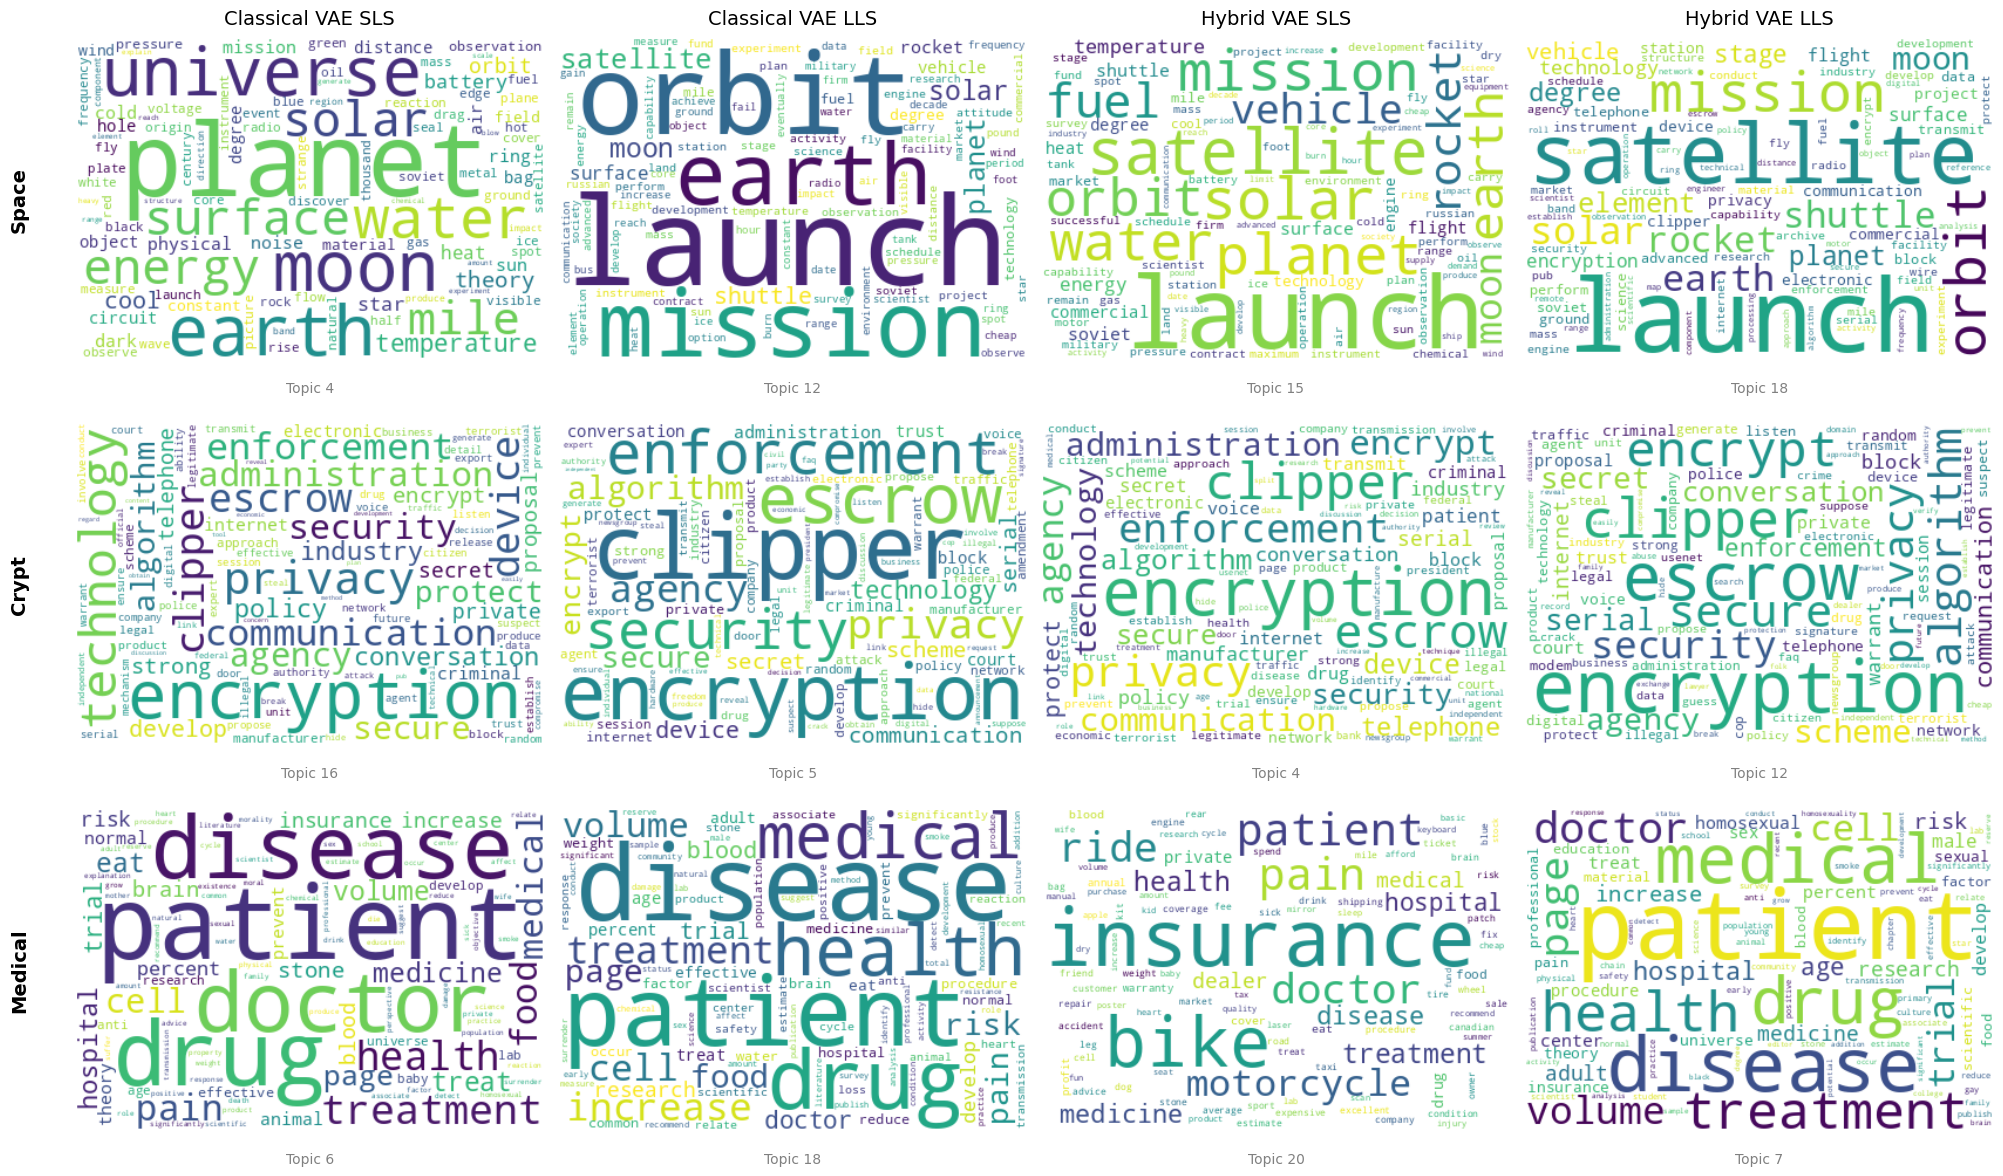

In [18]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import torch

def find_topic_by_keywords(topic_word_distributions, vocab_list, keywords):
    scores = []
    for topic_dist in topic_word_distributions:
        top_indices = topic_dist.argsort(descending=True)[:10]
        top_words = [vocab_list[idx] for idx in top_indices]
        score = sum(1 for k in keywords if k in top_words)
        scores.append(score)
    return np.argmax(scores)

model_keys = ["classical vae", "classical vae prob", "hybrid vae", "hybrid vae prob"]
topic_themes = {
    "Space": ["space", "nasa", "cassini", "moon", "saturn", "planet", "earth", "orbit", "solar", "mission", "satellite", "shuttle", "rocket", "universe", "star"],
    "Crypt": ["encryption", "clipper", "escrow", "cryptography", "algorithm", "secure", "privacy", "key", "security", "pgp"],
    "Medical": ["medical", "health", "doctor", "patient", "disease", "treatment", "medicine", "drug", "cure", "pain", "hospital", "cell", "risk", "cancer", "therapy"]
}

plot_data = {theme: [] for theme in topic_themes.keys()}

model_display_titles = {
    "classical vae": "Classical VAE SLS",
    "classical vae prob": "Classical VAE LLS",
    "hybrid vae": "Hybrid VAE SLS",
    "hybrid vae prob": "Hybrid VAE LLS"
}

for model_key in model_keys:
    model, vocab_list = load_model(model_classes[model_key], MODELS[model_key])
    topic_dist_all = model.get_topics().cpu()

    for theme, keywords in topic_themes.items():
        idx = find_topic_by_keywords(topic_dist_all, vocab_list, keywords)
        topic_dist = topic_dist_all[idx]

        word_probs = {vocab_list[j]: topic_dist[j].item() for j in range(len(vocab_list))}
        sorted_probs = sorted(word_probs.items(), key=lambda x: x[1], reverse=True)[:100]
        plot_data[theme].append({"words": dict(sorted_probs), "idx": idx, "model": model_key})

fig, axes = plt.subplots(len(topic_themes), 4, figsize=(20, len(topic_themes) * 4))
#fig.suptitle("Top 100 Word Clouds for Semantic Topics Across Models", fontsize=20, y=1.02)

for row_idx, (theme, results) in enumerate(plot_data.items()):
    for col_idx, res in enumerate(results):
        ax = axes[row_idx, col_idx]
        wc = WordCloud(width=400, height=275, background_color='white').generate_from_frequencies(res['words'])
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')

        if row_idx == 0:
            ax.set_title(model_display_titles[res['model']], fontsize=14, pad=10)
        if col_idx == 0:
            ax.text(-0.1, 0.5, theme, transform=ax.transAxes, rotation=90,
                    va='center', ha='right', fontsize=14, fontweight='bold')

        ax.text(0.5, -0.1, f"Topic {res['idx']+1}", transform=ax.transAxes,
                ha='center', fontsize=10, color='gray')

plt.tight_layout()

plt.savefig('word-clouds-20news.pdf', bbox_inches='tight')
plt.show()